# River Water Level Imputation

This notebook fills in missing monthly water level values for ten Burundi rivers using four models:

1. **LightGBM** – gradient boosted trees
2. **XGBoost** – gradient boosted trees
3. **ARIMAX** – ARIMA with external predictors
4. **SARIMAX** – ARIMAX with a yearly (12-month) seasonal component

For each river we pick the **best model** (the one with the lowest RMSE during validation) and use it to fill that river's missing values.

The notebook produces:

- A **model comparison** table with **MAE, RMSE, Bias and Sample size**.
- A **line chart per river** showing the filled missing values (best model) on top of the observed values.
- A **historical trends chart per river** with a 12-month rolling average.
- A final CSV with all imputed columns.


In [1]:
# ============================================================
# 1. IMPORTS AND DATA LOADING
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Plot style
plt.rcParams["figure.dpi"]  = 100
plt.rcParams["axes.grid"]   = True
plt.rcParams["grid.alpha"]  = 0.3
plt.rcParams["font.size"]   = 10


# ------------------------------------------------------------
# >>> UPDATE THIS PATH to point to your CSV <<<
# (Your file is master_dataset_inputed.csv — it already contains the
#  `ndvi` column needed by the predictors.)
# ------------------------------------------------------------
DATA_PATH = '../../data/outputs/master_dataset_inputed.csv'

rivers = pd.read_csv(DATA_PATH)
rivers_original = rivers.copy()

print(f"Loaded {rivers.shape[0]} rows, {rivers.shape[1]} columns")
print(f"Rivers found: {sorted(rivers['river'].dropna().unique())}")


# ------------------------------------------------------------
# SANITY CHECK: water level scale per river.
# All rivers should be on roughly the same scale (metres).
# If one river's max is 100x bigger than the others, that signals
# a unit mismatch (e.g. cm vs m) — investigate before modelling.
# ------------------------------------------------------------
scale_check = (
    rivers.groupby("river")["water_level"]
          .agg(["count", "min", "mean", "max", "std"])
          .round(2)
          .sort_values("mean")
)
print("\nWater level scale per river (sanity check):")
print(scale_check.to_string())


# ------------------------------------------------------------
# Build a proper date index (year + month -> 1st of the month)
# ------------------------------------------------------------
rivers["date"]          = pd.to_datetime(rivers[["year", "month"]].assign(day=1))
rivers_original["date"] = pd.to_datetime(rivers_original[["year", "month"]].assign(day=1))

rivers          = rivers.sort_values("date").set_index("date")
rivers_original = rivers_original.sort_values("date").set_index("date")


Loaded 4664 rows, 27 columns
Rivers found: ['Buzimba', 'Jiji', 'Kaburantwa', 'Mpanda', 'Mulembwe', 'Mutimbuzi', 'Nyakagunda', 'Nyamagana', 'Nyengwe', 'Rusizi']

Water level scale per river (sanity check):
            count   min  mean   max   std
river                                    
Nyakagunda    300  0.28  0.48  0.77  0.09
Nyamagana     336  0.18  0.60  1.35  0.27
Jiji          523  0.32  0.68  1.44  0.24
Nyengwe       252  0.09  0.86  2.00  0.39
Buzimba       344  0.20  0.99  1.98  0.44
Kaburantwa    339  0.08  1.01  2.88  0.68
Mpanda        171  0.57  1.25  1.80  0.30
Mulembwe      475  0.18  1.30  2.97  0.67
Mutimbuzi     130  0.33  1.58  3.00  0.66
Rusizi        361  0.19  2.00  4.45  1.05


## 2. Settings, feature engineering and models

We define the constants, the feature-engineering function (lags + rolling rainfall), the four models, and the metrics helper (**MAE, RMSE, Bias, NRMSE**).


In [2]:
# ============================================================
# 2. SETTINGS, FEATURES AND MODELS
# ============================================================

TARGET_COL    = "water_level"
RIVER_COL     = "river"
START_YEAR    = 2000      # NDVI is reliable from 2000 onwards
MASK_FRACTION = 0.20      # Hide 20% of observed values during validation
RANDOM_SEED   = 42
MIN_OBS       = 50        # Need at least this many observations per river


def create_features(df, target_col=TARGET_COL):
    """Build lag and rolling features for one river's time series."""
    df = df.copy().sort_index()

    # Month of year (captures seasonality)
    df["month"] = df.index.month

    # Precipitation lags
    for lag in [1, 2, 3, 6, 12]:
        df[f"precip_lag{lag}"] = df["precip_observed"].shift(lag)

    # Rolling rainfall totals (previous months only — no leakage)
    df["precip_3m"]  = df["precip_observed"].shift(1).rolling(3).sum()
    df["precip_6m"]  = df["precip_observed"].shift(1).rolling(6).sum()
    df["precip_12m"] = df["precip_observed"].shift(1).rolling(12).sum()

    # Weighted rainfall (recent months matter more)
    df["precip_weighted_3m"] = (
        df["precip_observed"].shift(1) * 0.5 +
        df["precip_observed"].shift(2) * 0.3 +
        df["precip_observed"].shift(3) * 0.2
    )

    # Temporary linear interpolation, used ONLY to build lag features
    df["water_level_temp"] = (
        df[target_col].interpolate(method="linear").ffill().bfill()
    )

    # Water-level lags
    for lag in [1, 2, 3, 6, 12]:
        df[f"level_lag{lag}"] = df["water_level_temp"].shift(lag)

    return df


predictors = [
    "temp_max_observed", "temp_min_observed", "precip_observed",
    "precip_lag1", "precip_lag2", "precip_lag3", "precip_lag6", "precip_lag12",
    "precip_3m", "precip_6m", "precip_12m", "precip_weighted_3m",
    "month", "ndvi",
    "level_lag1", "level_lag2", "level_lag3", "level_lag6", "level_lag12",
]


ml_models = {
    "LightGBM": LGBMRegressor(
        n_estimators=300, learning_rate=0.03,
        max_depth=3, num_leaves=8, min_child_samples=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_SEED, verbose=-1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.03,
        max_depth=3, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_SEED, objective="reg:squarederror",
    ),
}


def calculate_metrics(y_true, y_pred, train_y):
    """Returns MAE, RMSE, Bias (mean of predicted-actual), and NRMSE."""
    rmse  = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae   = float(mean_absolute_error(y_true, y_pred))
    bias  = float(np.mean(y_pred - y_true))
    nrmse = float(rmse / train_y.std()) if train_y.std() != 0 else np.nan
    return mae, rmse, bias, nrmse


## 3. Validation — hide 20% of known values, then try to predict them

We pretend 20% of the *observed* water levels are missing, fit each model on the rest, then check how close the predictions are to the real (hidden) values.


In [3]:
# ============================================================
# 3. VALIDATION LOOP
# ============================================================

validation_results = []
validation_predictions = []

np.random.seed(RANDOM_SEED)

for river_name in rivers[RIVER_COL].dropna().unique():

    df = rivers[rivers[RIVER_COL] == river_name].copy().sort_index()
    df = df[df.index.year >= START_YEAR].copy()

    observed_idx = df[df[TARGET_COL].notna()].index

    if len(observed_idx) < MIN_OBS:
        print(f"Skipping {river_name}: not enough observed values.")
        continue

    # Hide 20% of observed values at random
    masked_idx = np.random.choice(
        observed_idx,
        size=int(len(observed_idx) * MASK_FRACTION),
        replace=False,
    )

    df_val = df.copy()
    true_values = df_val.loc[masked_idx, TARGET_COL].copy()
    df_val.loc[masked_idx, TARGET_COL] = np.nan

    # Build features AFTER masking so the lags don't leak the hidden values
    df_val = create_features(df_val, target_col=TARGET_COL)
    available_predictor_rows = df_val[predictors].notna().any(axis=1)

    train_df = df_val[df_val[TARGET_COL].notna() & available_predictor_rows].copy()
    test_df  = df_val.loc[masked_idx].copy()
    test_df  = test_df[test_df[predictors].notna().any(axis=1)]

    if len(train_df) < MIN_OBS or len(test_df) == 0:
        print(f"Skipping {river_name}: not enough train/test rows.")
        continue

    y_train = train_df[TARGET_COL]
    X_train = train_df[predictors]
    X_test  = test_df[predictors]
    y_test  = true_values.loc[test_df.index]

    imputer = SimpleImputer(strategy="mean")
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp  = imputer.transform(X_test)

    # --- LightGBM & XGBoost ---
    for model_name, model in ml_models.items():
        model.fit(X_train_imp, y_train)
        preds = model.predict(X_test_imp)

        mae, rmse, bias, nrmse = calculate_metrics(y_test, preds, y_train)
        validation_results.append({
            "river": river_name, "model": model_name,
            "n_train": len(train_df), "n_test_masked": len(test_df),
            "mae": mae, "rmse": rmse, "bias": bias, "nrmse": nrmse,
        })
        validation_predictions.append(pd.DataFrame({
            "river": river_name, "model": model_name,
            "date": test_df.index,
            "true_water_level": y_test.values,
            "predicted_water_level": preds,
            "error": preds - y_test.values,
        }))

    # --- ARIMAX (no seasonal term) ---
    try:
        df_arimax = df_val[df_val[predictors].notna().any(axis=1)].copy()
        y_a = df_arimax[TARGET_COL]
        X_a = SimpleImputer(strategy="mean").fit_transform(df_arimax[predictors])

        arimax_fit = SARIMAX(
            y_a, exog=X_a,
            order=(1, 0, 1), seasonal_order=(0, 0, 0, 0),
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)

        arimax_pred_all = arimax_fit.predict(start=0, end=len(df_arimax) - 1, exog=X_a)
        arimax_preds = pd.Series(arimax_pred_all, index=df_arimax.index).loc[test_df.index]

        mae, rmse, bias, nrmse = calculate_metrics(y_test, arimax_preds, y_train)
        validation_results.append({
            "river": river_name, "model": "ARIMAX",
            "n_train": len(train_df), "n_test_masked": len(test_df),
            "mae": mae, "rmse": rmse, "bias": bias, "nrmse": nrmse,
        })
        validation_predictions.append(pd.DataFrame({
            "river": river_name, "model": "ARIMAX",
            "date": test_df.index,
            "true_water_level": y_test.values,
            "predicted_water_level": arimax_preds.values,
            "error": arimax_preds.values - y_test.values,
        }))
    except Exception as e:
        print(f"ARIMAX failed for {river_name}: {e}")

    # --- SARIMAX (12-month seasonal) ---
    try:
        df_sarimax = df_val[df_val[predictors].notna().any(axis=1)].copy()
        y_s = df_sarimax[TARGET_COL]
        X_s = SimpleImputer(strategy="mean").fit_transform(df_sarimax[predictors])

        sarimax_fit = SARIMAX(
            y_s, exog=X_s,
            order=(1, 0, 1), seasonal_order=(1, 0, 1, 12),
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)

        sarimax_pred_all = sarimax_fit.predict(start=0, end=len(df_sarimax) - 1, exog=X_s)
        sarimax_preds = pd.Series(sarimax_pred_all, index=df_sarimax.index).loc[test_df.index]

        mae, rmse, bias, nrmse = calculate_metrics(y_test, sarimax_preds, y_train)
        validation_results.append({
            "river": river_name, "model": "SARIMAX",
            "n_train": len(train_df), "n_test_masked": len(test_df),
            "mae": mae, "rmse": rmse, "bias": bias, "nrmse": nrmse,
        })
        validation_predictions.append(pd.DataFrame({
            "river": river_name, "model": "SARIMAX",
            "date": test_df.index,
            "true_water_level": y_test.values,
            "predicted_water_level": sarimax_preds.values,
            "error": sarimax_preds.values - y_test.values,
        }))
    except Exception as e:
        print(f"SARIMAX failed for {river_name}: {e}")


validation_results_df     = pd.DataFrame(validation_results)
validation_predictions_df = pd.concat(validation_predictions, ignore_index=True)

print(f"\nValidation done. {validation_results_df.shape[0]} (river, model) pairs scored.")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versi


Validation done. 40 (river, model) pairs scored.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 4. Model comparison — MAE, RMSE, Bias, Sample size

| Metric | What it means | Better when |
|---|---|---|
| **MAE**  | average absolute error in metres | smaller |
| **RMSE** | root mean squared error in metres (punishes big misses) | smaller |
| **Bias** | average (predicted − actual); positive = model over-predicts | closer to 0 |
| **Sample size** | how many masked observations were used to score the model | informational |


In [4]:
# ============================================================
# 4. MODEL COMPARISON
# ============================================================

# 4a. Overall comparison (one row per model)
model_comparison = (
    validation_results_df
      .groupby("model")
      .agg(
          MAE           = ("mae",           "mean"),
          RMSE          = ("rmse",          "mean"),
          Bias          = ("bias",          "mean"),
          Sample_size   = ("n_test_masked", "sum"),
          Rivers_tested = ("river",         "nunique"),
      )
      .reset_index()
      .sort_values("RMSE")
      .reset_index(drop=True)
      .round({"MAE": 3, "RMSE": 3, "Bias": 3})
)

print("Overall model comparison (averaged across rivers):")
print(model_comparison.to_string(index=False))


# 4b. Per-river comparison (one row per river-model pair)
model_comparison_per_river = (
    validation_results_df
      .rename(columns={
          "mae": "MAE", "rmse": "RMSE", "bias": "Bias",
          "n_test_masked": "Sample_size",
      })
      [["river", "model", "MAE", "RMSE", "Bias", "Sample_size"]]
      .sort_values(["river", "RMSE"])
      .reset_index(drop=True)
      .round({"MAE": 3, "RMSE": 3, "Bias": 3})
)

print("\nPer-river, per-model comparison:")
print(model_comparison_per_river.to_string(index=False))


# 4c. Best model per river (lowest RMSE)
best_model_per_river = (
    validation_results_df
      .sort_values(["river", "rmse"])
      .groupby("river")
      .first()
      .reset_index()
      .rename(columns={
          "mae": "MAE", "rmse": "RMSE", "bias": "Bias",
          "n_test_masked": "Sample_size",
      })
      [["river", "model", "MAE", "RMSE", "Bias", "Sample_size"]]
      .round({"MAE": 3, "RMSE": 3, "Bias": 3})
)

print("\nBest model per river (lowest RMSE):")
print(best_model_per_river.to_string(index=False))


# 4d. How many rivers does each model "win"?
model_win_counts = (
    best_model_per_river["model"]
      .value_counts()
      .rename_axis("model")
      .reset_index(name="number_of_rivers_best")
)
print("\nNumber of rivers where each model performed best:")
print(model_win_counts.to_string(index=False))


overall_best_model = model_comparison.iloc[0]["model"]
print(f"\nOverall best model based on mean RMSE: {overall_best_model}")


Overall model comparison (averaged across rivers):
   model   MAE  RMSE   Bias  Sample_size  Rivers_tested
 XGBoost 0.106 0.141 -0.026          355             10
LightGBM 0.107 0.142 -0.022          355             10
  ARIMAX 0.113 0.149 -0.019          355             10
 SARIMAX 0.113 0.149 -0.021          355             10

Per-river, per-model comparison:
     river    model   MAE  RMSE   Bias  Sample_size
   Buzimba  SARIMAX 0.083 0.117 -0.029           26
   Buzimba   ARIMAX 0.088 0.119 -0.016           26
   Buzimba  XGBoost 0.098 0.124 -0.026           26
   Buzimba LightGBM 0.101 0.128 -0.009           26
      Jiji  XGBoost 0.069 0.102 -0.008           59
      Jiji LightGBM 0.072 0.102 -0.003           59
      Jiji   ARIMAX 0.085 0.115 -0.004           59
      Jiji  SARIMAX 0.086 0.116 -0.004           59
Kaburantwa  XGBoost 0.115 0.141 -0.010           37
Kaburantwa LightGBM 0.117 0.145  0.008           37
Kaburantwa   ARIMAX 0.118 0.149  0.041           37
Kaburantwa 

## 5. Final imputation — fill the actual missing values

We use **all observed data** (nothing hidden) to fit each model on each river and predict where `water_level` is genuinely missing. Four new columns are added (one per model) plus matching `_method` columns showing `"observed"` or the model name.


In [5]:
# ============================================================
# 5. FINAL IMPUTATION (all 4 models)
# ============================================================

rivers_imputed = rivers.copy()

# Initialise output columns
for model_name in ["LightGBM", "XGBoost", "ARIMAX", "SARIMAX"]:
    rivers_imputed[f"water_level_{model_name}_imputed"] = rivers_imputed[TARGET_COL]
    rivers_imputed[f"water_level_{model_name}_method"]  = np.where(
        rivers_imputed[TARGET_COL].notna(), "observed", "missing"
    )


for river_name in rivers[RIVER_COL].dropna().unique():

    df = rivers[rivers[RIVER_COL] == river_name].copy().sort_index()
    df = df[df.index.year >= START_YEAR].copy()

    df_features = create_features(df, target_col=TARGET_COL)
    df_features = df_features[df_features[predictors].notna().any(axis=1)].copy()

    observed_df = df_features[df_features[TARGET_COL].notna()].copy()
    missing_df  = df_features[df_features[TARGET_COL].isna()].copy()

    if len(observed_df) < MIN_OBS or len(missing_df) == 0:
        print(f"Skipping {river_name}: not enough data or no missing values.")
        continue

    X_train = observed_df[predictors]
    y_train = observed_df[TARGET_COL]
    X_missing = missing_df[predictors]

    imputer = SimpleImputer(strategy="mean")
    X_train_imp   = imputer.fit_transform(X_train)
    X_missing_imp = imputer.transform(X_missing)

    target_mask = (
        (rivers_imputed[RIVER_COL] == river_name) &
        (rivers_imputed.index.isin(missing_df.index))
    )

    # LightGBM + XGBoost
    for model_name, model in ml_models.items():
        model.fit(X_train_imp, y_train)
        preds = model.predict(X_missing_imp)
        if target_mask.sum() != len(preds):
            print(f"Length mismatch ({river_name}, {model_name})")
            continue
        rivers_imputed.loc[target_mask, f"water_level_{model_name}_imputed"] = preds
        rivers_imputed.loc[target_mask, f"water_level_{model_name}_method"]  = model_name

    # ARIMAX
    try:
        y_all = df_features[TARGET_COL]
        X_all = SimpleImputer(strategy="mean").fit_transform(df_features[predictors])

        fit = SARIMAX(
            y_all, exog=X_all,
            order=(1, 0, 1), seasonal_order=(0, 0, 0, 0),
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)

        pred_all = fit.predict(start=0, end=len(df_features) - 1, exog=X_all)
        preds = pd.Series(pred_all, index=df_features.index).loc[missing_df.index]

        if target_mask.sum() == len(preds):
            rivers_imputed.loc[target_mask, "water_level_ARIMAX_imputed"] = preds.values
            rivers_imputed.loc[target_mask, "water_level_ARIMAX_method"]  = "ARIMAX"
    except Exception as e:
        print(f"ARIMAX failed for {river_name}: {e}")

    # SARIMAX
    try:
        y_all = df_features[TARGET_COL]
        X_all = SimpleImputer(strategy="mean").fit_transform(df_features[predictors])

        fit = SARIMAX(
            y_all, exog=X_all,
            order=(1, 0, 1), seasonal_order=(1, 0, 1, 12),
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)

        pred_all = fit.predict(start=0, end=len(df_features) - 1, exog=X_all)
        preds = pd.Series(pred_all, index=df_features.index).loc[missing_df.index]

        if target_mask.sum() == len(preds):
            rivers_imputed.loc[target_mask, "water_level_SARIMAX_imputed"] = preds.values
            rivers_imputed.loc[target_mask, "water_level_SARIMAX_method"]  = "SARIMAX"
    except Exception as e:
        print(f"SARIMAX failed for {river_name}: {e}")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Pyt

## 6. Build the best-model column (with a divergence safeguard)

We already know which model won the validation for each river. But validation hides only short, scattered gaps — it can miss the case where a time-series model (ARIMAX or SARIMAX) becomes unstable over a **long continuous gap** and produces wildly impossible values (e.g. −1094 m).

So before trusting the validation winner, we check that its predictions for the actually-missing rows stay within a sensible range around the observed water levels. If they don't, we **fall back to the next-best model** for that river and print a warning.

We also clip the final column at 0, because water level can't be negative.


In [6]:
# ============================================================
# 6. BEST-MODEL-PER-RIVER COLUMN (with divergence safeguard)
# ============================================================
#
# Time-series models (ARIMAX/SARIMAX) can diverge over long gaps of
# missing y values — predictions explode to +/- huge numbers.
# Validation can miss this because it uses short, scattered gaps.
#
# Fix: for each river, walk the candidate models from lowest RMSE to
# highest. Pick the first model whose final-imputation predictions
# stay within a plausible range around the observed water levels.
# This way, if ARIMAX explodes for Mulembwe's 2-year gap, we silently
# fall back to LightGBM (or whichever model is next-best).
# ============================================================

# Rank candidate models per river by validation RMSE (best first)
ranked_models_per_river = (
    validation_results_df
      .sort_values(["river", "rmse"])
      .groupby("river")["model"]
      .apply(list)
      .to_dict()
)


def predictions_look_sane(preds, obs_min, obs_max, max_bad_fraction=0.05):
    """
    Return True if at most `max_bad_fraction` of preds fall outside a
    lenient range around the observed min/max. Water level cannot be
    negative, so anything < 0 is automatically bad.
    """
    if len(preds) == 0:
        return True
    obs_range = max(obs_max - obs_min, 0.1)  # avoid zero range
    lower = max(0.0, obs_min - obs_range)    # never below 0
    upper = obs_max + obs_range
    bad = ((preds < lower) | (preds > upper)).mean()
    return bad <= max_bad_fraction


best_model_lookup = {}
fallback_log = []

for river_name, candidates in ranked_models_per_river.items():
    river_mask = (rivers_imputed[RIVER_COL] == river_name)
    observed_vals = rivers_imputed.loc[river_mask, TARGET_COL].dropna()
    if observed_vals.empty:
        continue
    obs_min, obs_max = observed_vals.min(), observed_vals.max()
    missing_mask = river_mask & rivers_imputed[TARGET_COL].isna()

    chosen = None
    for model_name in candidates:
        col = f"water_level_{model_name}_imputed"
        preds = rivers_imputed.loc[missing_mask, col].dropna().values
        if predictions_look_sane(preds, obs_min, obs_max):
            chosen = model_name
            break

    # Fallback: if every model diverged (very unlikely), keep the
    # validation winner but flag it loudly.
    if chosen is None:
        chosen = candidates[0]
        fallback_log.append(f"  WARNING: all models diverged for {river_name}, using {chosen}")

    best_model_lookup[river_name] = chosen

    # Log when we did NOT pick the validation winner
    if chosen != candidates[0]:
        fallback_log.append(
            f"  {river_name}: validation winner was {candidates[0]} but its predictions "
            f"diverged; falling back to {chosen}."
        )


# Build the final best-model column
rivers_imputed["water_level_best_model_imputed"] = rivers_imputed[TARGET_COL]
rivers_imputed["best_model_used"] = np.where(
    rivers_imputed[TARGET_COL].notna(), "observed", "missing"
)

for river_name, best_model in best_model_lookup.items():
    missing_mask = (
        (rivers_imputed[RIVER_COL] == river_name) &
        (rivers_imputed[TARGET_COL].isna())
    )
    best_col = f"water_level_{best_model}_imputed"
    rivers_imputed.loc[missing_mask, "water_level_best_model_imputed"] = (
        rivers_imputed.loc[missing_mask, best_col]
    )
    rivers_imputed.loc[missing_mask, "best_model_used"] = best_model


# Hard safety net: water level cannot be negative.
rivers_imputed["water_level_best_model_imputed"] = (
    rivers_imputed["water_level_best_model_imputed"].clip(lower=0)
)


# Keep only data from 2000 onwards (matches the modelling window)
rivers_imputed = rivers_imputed[rivers_imputed.index.year >= 2000].copy()


print("Best model per river (after divergence check):")
for r in sorted(best_model_lookup):
    print(f"  {r:12s} -> {best_model_lookup[r]}")

if fallback_log:
    print("\nFallbacks applied:")
    for line in fallback_log:
        print(line)


Best model per river (after divergence check):
  Buzimba      -> SARIMAX
  Jiji         -> XGBoost
  Kaburantwa   -> XGBoost
  Mpanda       -> XGBoost
  Mulembwe     -> XGBoost
  Mutimbuzi    -> LightGBM
  Nyakagunda   -> LightGBM
  Nyamagana    -> XGBoost
  Nyengwe      -> LightGBM
  Rusizi       -> XGBoost

Fallbacks applied:
  Mulembwe: validation winner was ARIMAX but its predictions diverged; falling back to XGBoost.


## 7. Line chart — filled missing water levels (best model) per river

One chart per river. Each chart shows:

- **Blue line** — the complete series after imputation (observed + filled)
- **Grey dots** — values that were originally observed
- **Orange dots** — values that were originally missing and have now been filled by the best model

The y-axis is fixed to the data's actual range, so any column-mix-up (e.g. plotting precipitation by mistake) would be immediately visible.


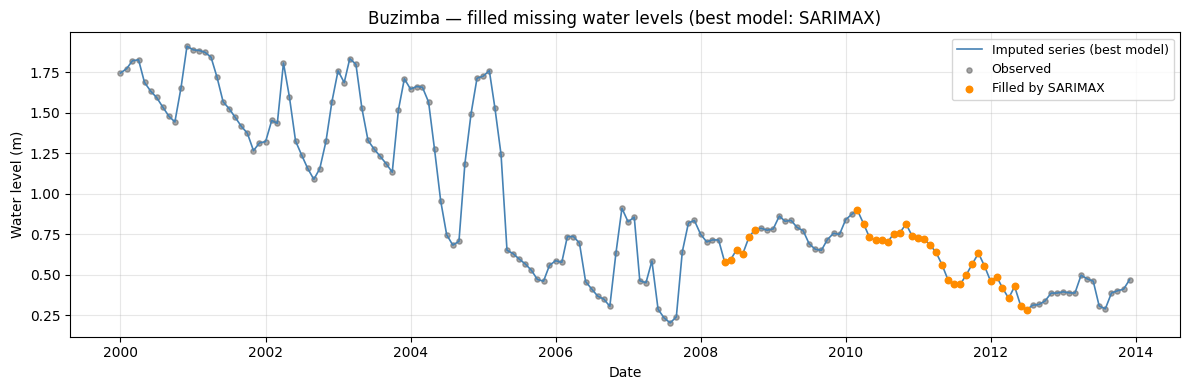

  Buzimba: observed=133, filled=35, range=[0.20, 1.91] m


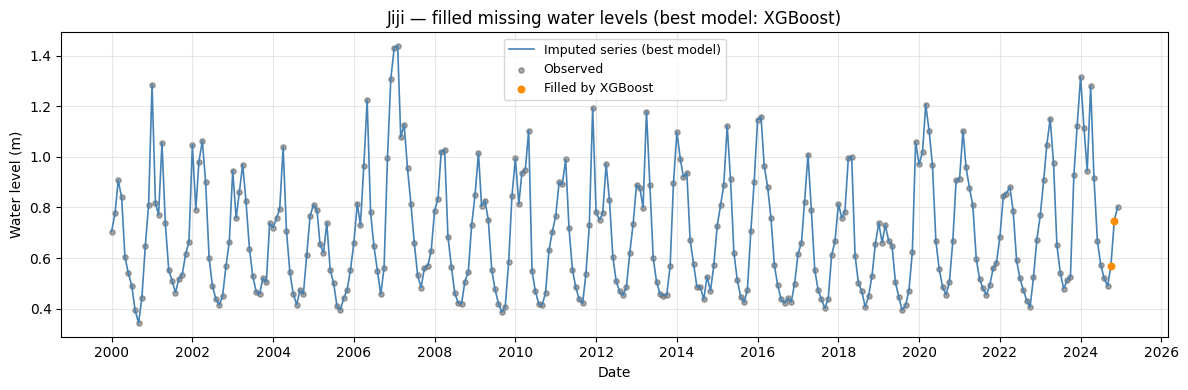

  Jiji: observed=298, filled=2, range=[0.34, 1.44] m


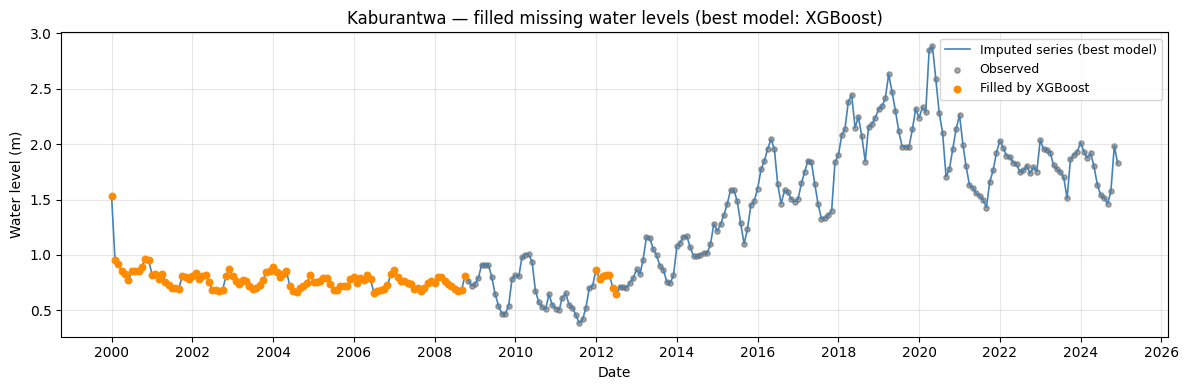

  Kaburantwa: observed=187, filled=113, range=[0.39, 2.88] m


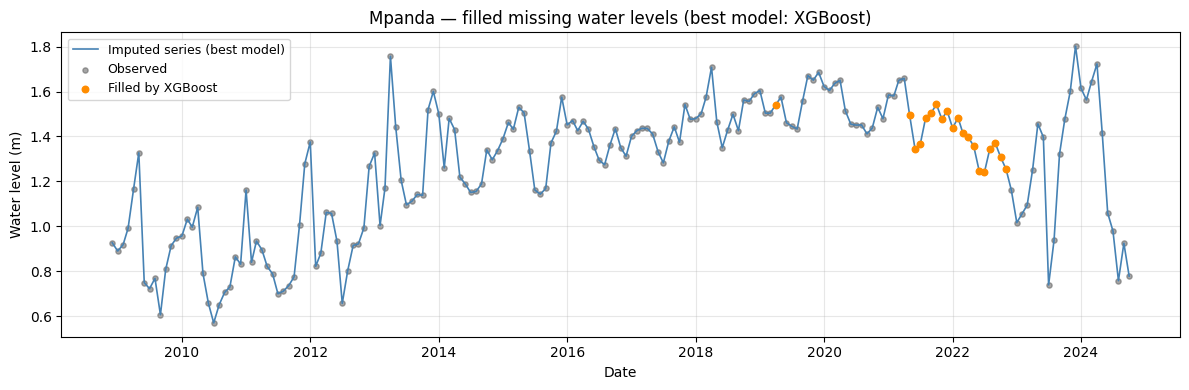

  Mpanda: observed=171, filled=20, range=[0.57, 1.80] m


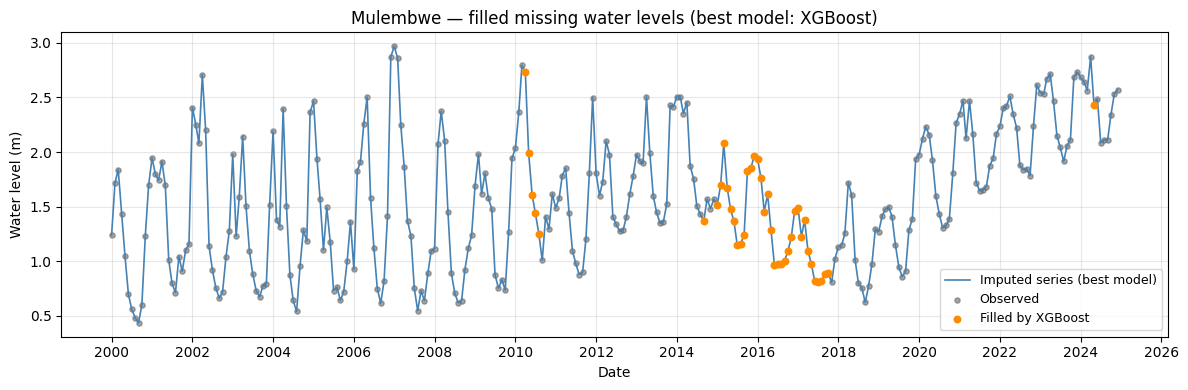

  Mulembwe: observed=259, filled=41, range=[0.44, 2.97] m


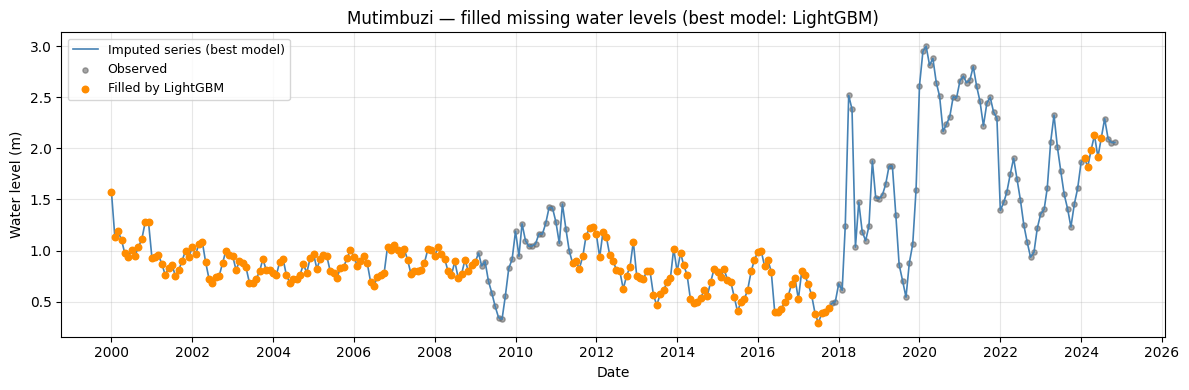

  Mutimbuzi: observed=107, filled=192, range=[0.29, 3.00] m


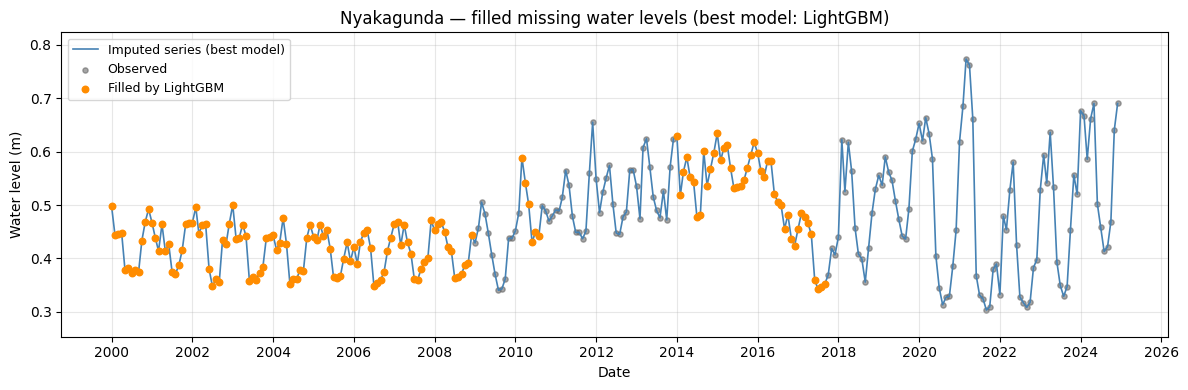

  Nyakagunda: observed=141, filled=159, range=[0.30, 0.77] m


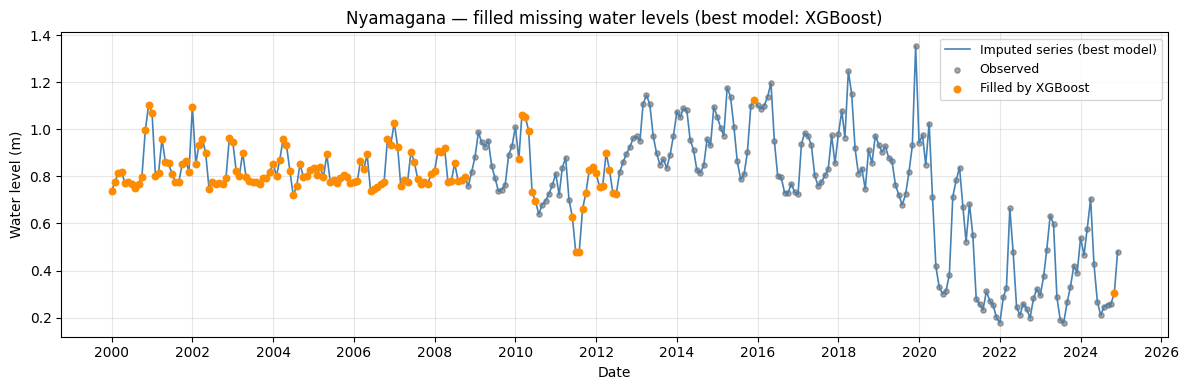

  Nyamagana: observed=172, filled=128, range=[0.18, 1.35] m


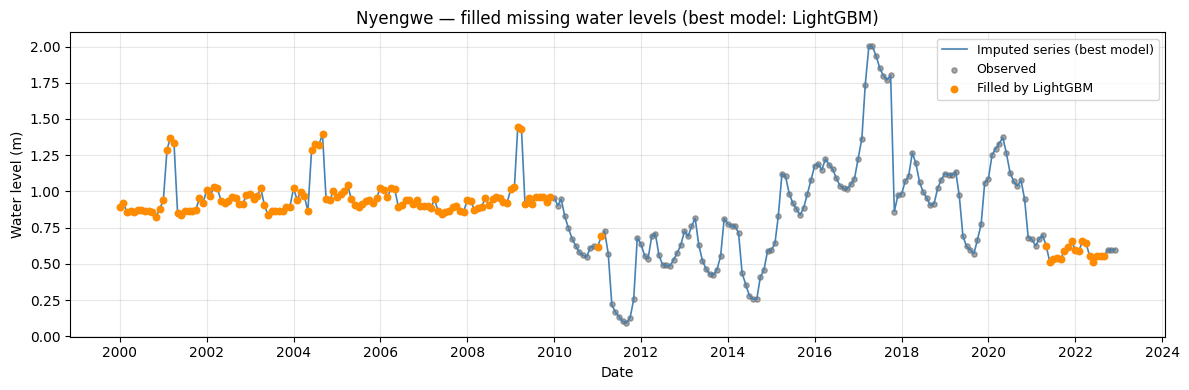

  Nyengwe: observed=137, filled=139, range=[0.09, 2.00] m


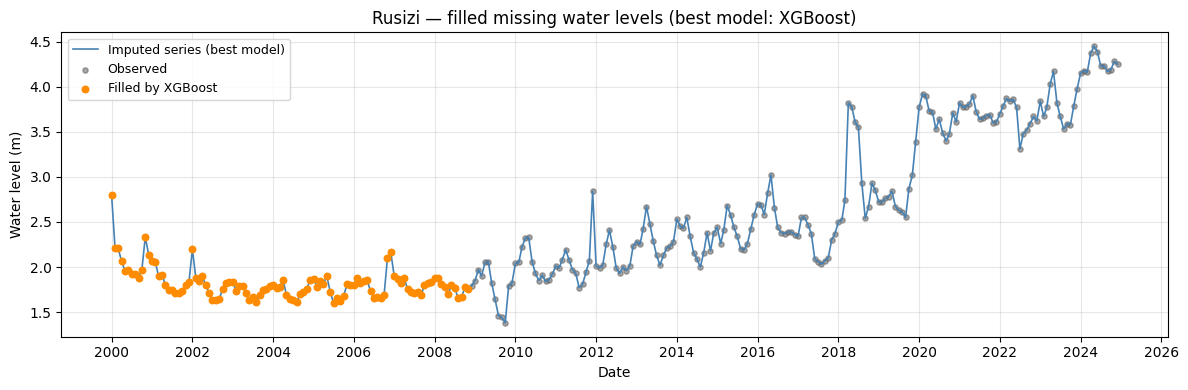

  Rusizi: observed=193, filled=107, range=[1.38, 4.45] m


In [7]:
# ============================================================
# 7. LINE CHART: FILLED MISSING VALUES (BEST MODEL) PER RIVER
# ============================================================

PLOT_COL = "water_level_best_model_imputed"

# Sanity check: make sure we're plotting a water_level column, not precipitation
assert PLOT_COL.startswith("water_level"), (
    f"PLOT_COL must be a water_level column, got '{PLOT_COL}'"
)

river_names = sorted(rivers_imputed[RIVER_COL].dropna().unique())

for river_name in river_names:

    df_plot = rivers_imputed[rivers_imputed[RIVER_COL] == river_name].copy().sort_index()

    series = df_plot[PLOT_COL].dropna()
    if series.empty:
        print(f"No data to plot for {river_name}.")
        continue

    best_model = best_model_lookup.get(river_name, "n/a")
    observed_only = df_plot[df_plot["best_model_used"] == "observed"]
    filled_only   = df_plot[df_plot["best_model_used"] != "observed"].dropna(subset=[PLOT_COL])

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(df_plot.index, df_plot[PLOT_COL],
            color="steelblue", linewidth=1.2, label="Imputed series (best model)")

    ax.scatter(observed_only.index, observed_only[PLOT_COL],
               color="dimgray", s=14, alpha=0.6, label="Observed")

    ax.scatter(filled_only.index, filled_only[PLOT_COL],
               color="darkorange", s=22, zorder=3, label=f"Filled by {best_model}")

    # Pin y-axis to the actual data range (+/-5% padding).
    # This prevents accidental 0-1000 axes if a wrong column is plotted.
    y_min, y_max = series.min(), series.max()
    pad = max(0.05 * (y_max - y_min), 0.05)
    ax.set_ylim(y_min - pad, y_max + pad)

    ax.set_title(f"{river_name} — filled missing water levels (best model: {best_model})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Water level (m)")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"  {river_name}: observed={len(observed_only)}, "
          f"filled={len(filled_only)}, range=[{y_min:.2f}, {y_max:.2f}] m")


## 8. Historical trends chart — water level per river

One chart per river showing only the **observed** water level over time, plus a **12-month rolling average** to highlight the long-term trend. No imputed values appear here — this is the raw historical view.


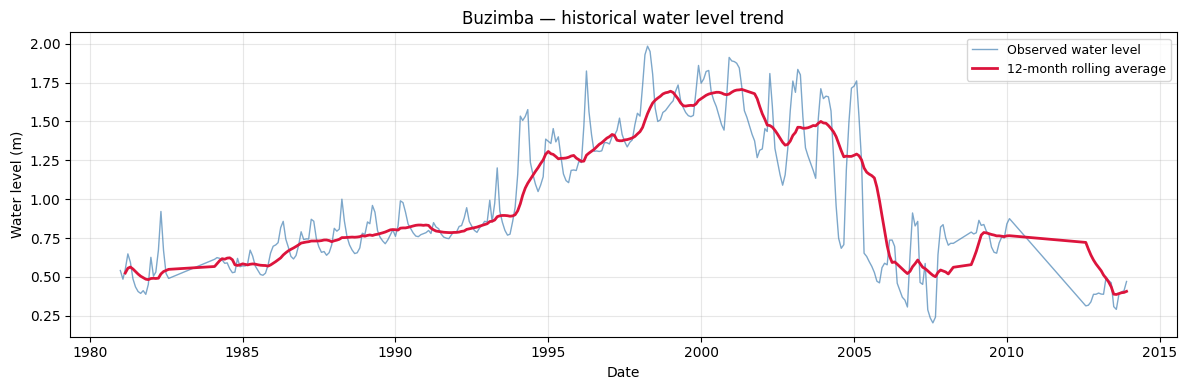

  Buzimba: start=1981-01-01, end=2013-12-01, n_obs=344, mean=0.99 m, min=0.20 m, max=1.98 m


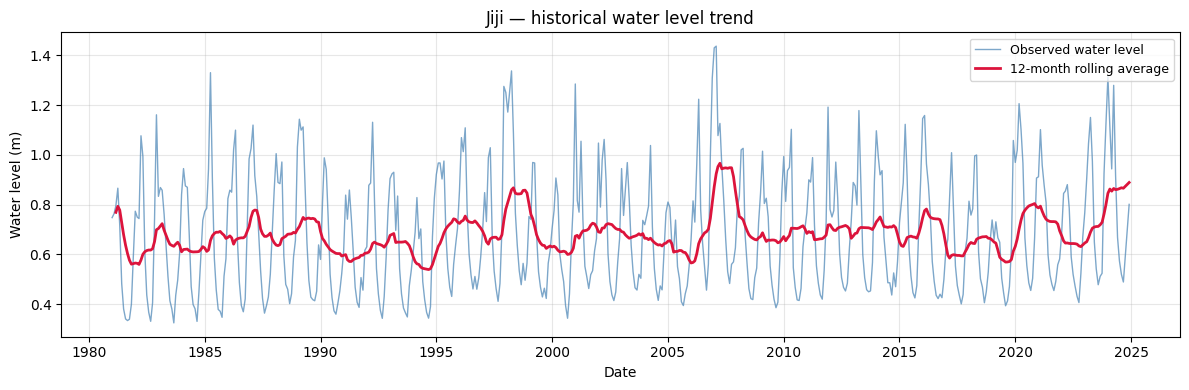

  Jiji: start=1981-01-01, end=2024-12-01, n_obs=523, mean=0.68 m, min=0.32 m, max=1.44 m


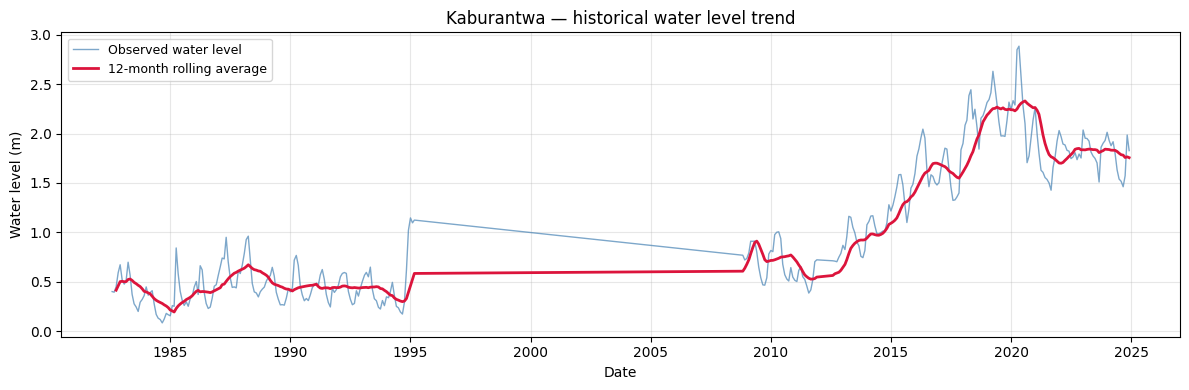

  Kaburantwa: start=1982-08-01, end=2024-12-01, n_obs=339, mean=1.01 m, min=0.08 m, max=2.88 m


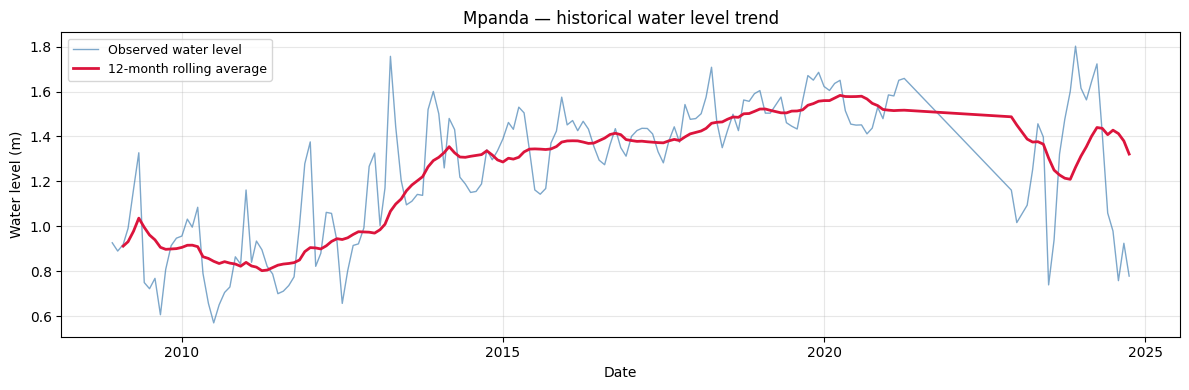

  Mpanda: start=2008-12-01, end=2024-10-01, n_obs=171, mean=1.25 m, min=0.57 m, max=1.80 m


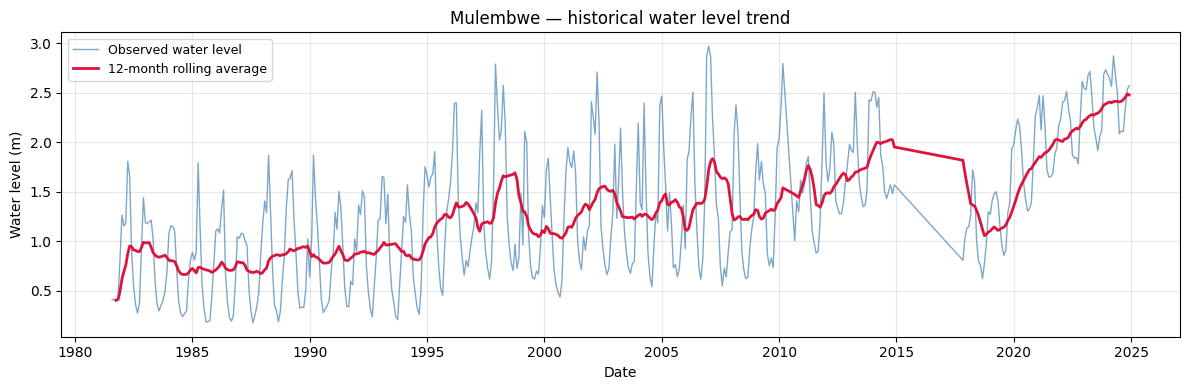

  Mulembwe: start=1981-08-01, end=2024-12-01, n_obs=475, mean=1.30 m, min=0.18 m, max=2.97 m


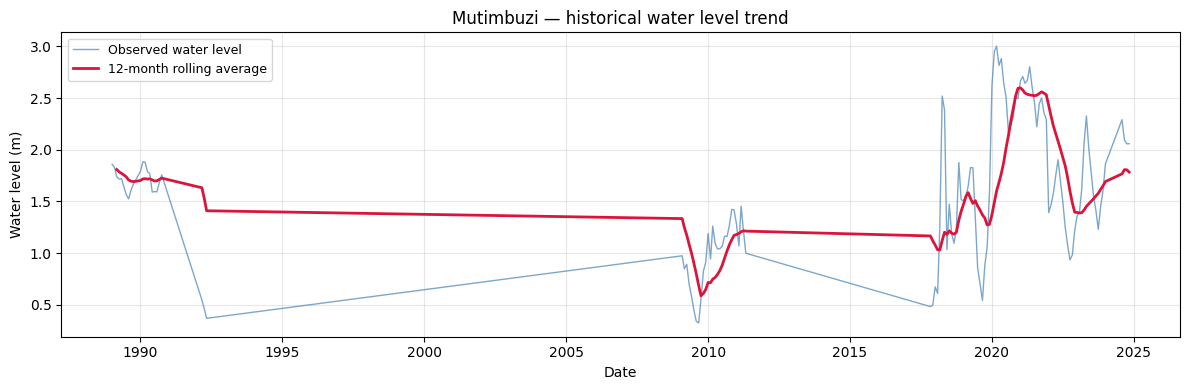

  Mutimbuzi: start=1989-01-01, end=2024-11-01, n_obs=130, mean=1.58 m, min=0.33 m, max=3.00 m


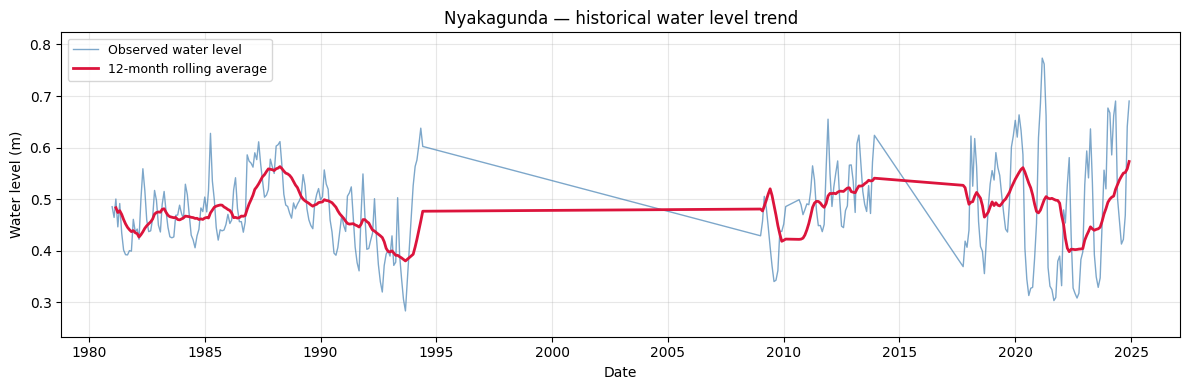

  Nyakagunda: start=1981-01-01, end=2024-12-01, n_obs=300, mean=0.48 m, min=0.28 m, max=0.77 m


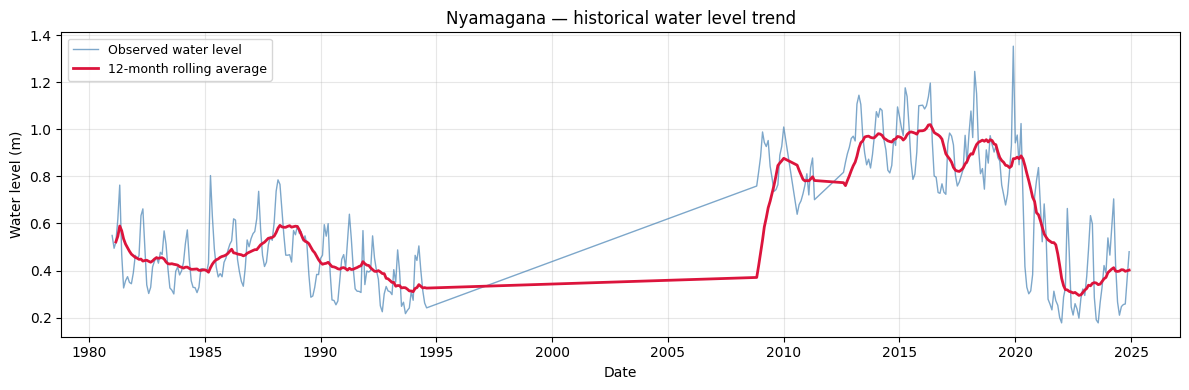

  Nyamagana: start=1981-01-01, end=2024-12-01, n_obs=336, mean=0.60 m, min=0.18 m, max=1.35 m


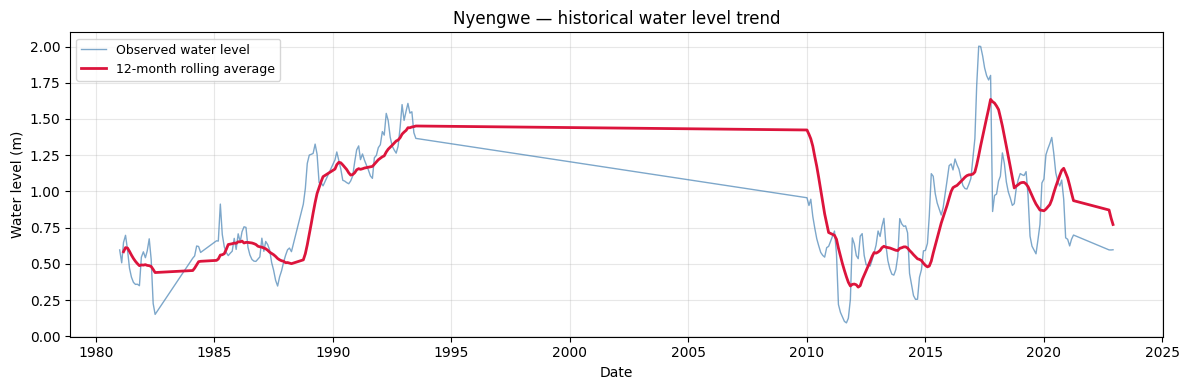

  Nyengwe: start=1981-01-01, end=2022-12-01, n_obs=252, mean=0.86 m, min=0.09 m, max=2.00 m


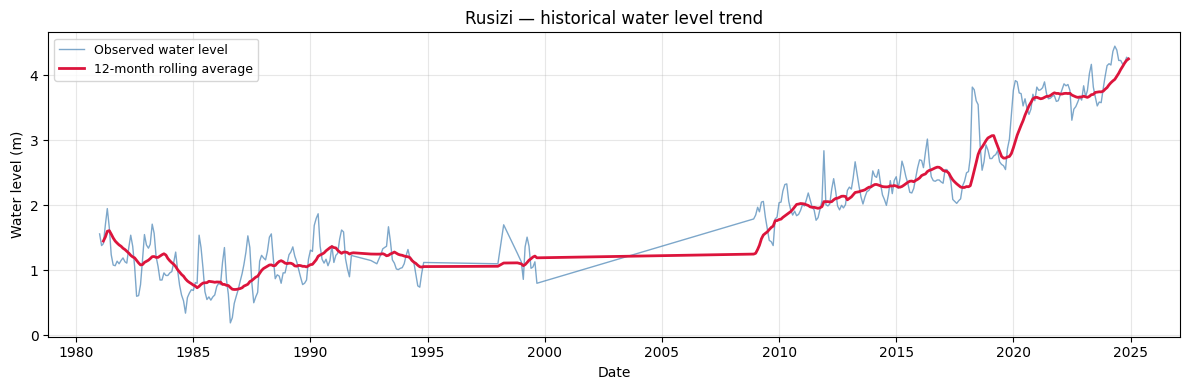

  Rusizi: start=1981-01-01, end=2024-12-01, n_obs=361, mean=2.00 m, min=0.19 m, max=4.45 m


In [8]:
# ============================================================
# 8. HISTORICAL TRENDS CHART (OBSERVED ONLY) PER RIVER
# ============================================================

for river_name in river_names:

    df_hist = rivers_original[rivers_original[RIVER_COL] == river_name].copy().sort_index()
    series  = df_hist[TARGET_COL].dropna()

    if series.empty:
        print(f"No observed history for {river_name}.")
        continue

    rolling = series.rolling(window=12, min_periods=3).mean()

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(series.index, series.values,
            color="steelblue", linewidth=1.0, alpha=0.7,
            label="Observed water level")
    ax.plot(rolling.index, rolling.values,
            color="crimson", linewidth=2.0,
            label="12-month rolling average")

    # Pin y-axis to the actual data range
    y_min, y_max = series.min(), series.max()
    pad = max(0.05 * (y_max - y_min), 0.05)
    ax.set_ylim(y_min - pad, y_max + pad)

    ax.set_title(f"{river_name} — historical water level trend")
    ax.set_xlabel("Date")
    ax.set_ylabel("Water level (m)")
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

    print(
        f"  {river_name}: "
        f"start={series.index.min().date()}, "
        f"end={series.index.max().date()}, "
        f"n_obs={len(series)}, "
        f"mean={series.mean():.2f} m, "
        f"min={series.min():.2f} m, "
        f"max={series.max():.2f} m"
    )


## 9. Final preview and save

The final dataset has one row per (river, month) and contains:

- `water_level` — original (still has NaNs where data is missing)
- `water_level_{LightGBM,XGBoost,ARIMAX,SARIMAX}_imputed` — filled by each model
- `water_level_best_model_imputed` — filled using the best model for that river
- `best_model_used` — `"observed"` if real, otherwise the model name

The final table is saved to `rivers_imputed.csv` next to this notebook.


In [9]:
# ============================================================
# 9. FINAL PREVIEW AND SAVE
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

preview = rivers_imputed[
    rivers_imputed["best_model_used"] != "observed"
][[
    RIVER_COL,
    "water_level",
    "water_level_LightGBM_imputed",
    "water_level_XGBoost_imputed",
    "water_level_ARIMAX_imputed",
    "water_level_SARIMAX_imputed",
    "water_level_best_model_imputed",
    "best_model_used",
]].head(20)

print("Sample of filled rows:")
print(preview)

# Save final imputed dataset
OUTPUT_CSV = "rivers_imputed.csv"
rivers_imputed.to_csv(OUTPUT_CSV)
print(f"\nSaved {len(rivers_imputed)} rows to {OUTPUT_CSV}")


Sample of filled rows:
                 river  water_level  water_level_LightGBM_imputed  \
date                                                                
2000-01-01   Nyamagana          NaN                      0.745182   
2000-01-01  Kaburantwa          NaN                      1.541039   
2000-01-01     Nyengwe          NaN                      0.890016   
2000-01-01   Mutimbuzi          NaN                      1.575930   
2000-01-01      Rusizi          NaN                      2.834729   
2000-01-01  Nyakagunda          NaN                      0.497807   
2000-02-01     Nyengwe          NaN                      0.919100   
2000-02-01   Mutimbuzi          NaN                      1.128504   
2000-02-01  Kaburantwa          NaN                      0.948949   
2000-02-01  Nyakagunda          NaN                      0.443238   
2000-02-01      Rusizi          NaN                      2.093332   
2000-02-01   Nyamagana          NaN                      0.774555   
2000-03-01 